C:\Users\huyen\AppData\Local\Temp\ipykernel_17828\4253170129.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=acc_per_cat, x='Category', y='Is_Pass', palette='viridis')
C:\Users\huyen\AppData\Local\Temp\ipykernel_17828\4253170129.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_latency, x='Total Response Time (ms)', y='Expected Intent', palette='magma')


Đã xuất xong 3 biểu đồ chuẩn độ phân giải cực cao!


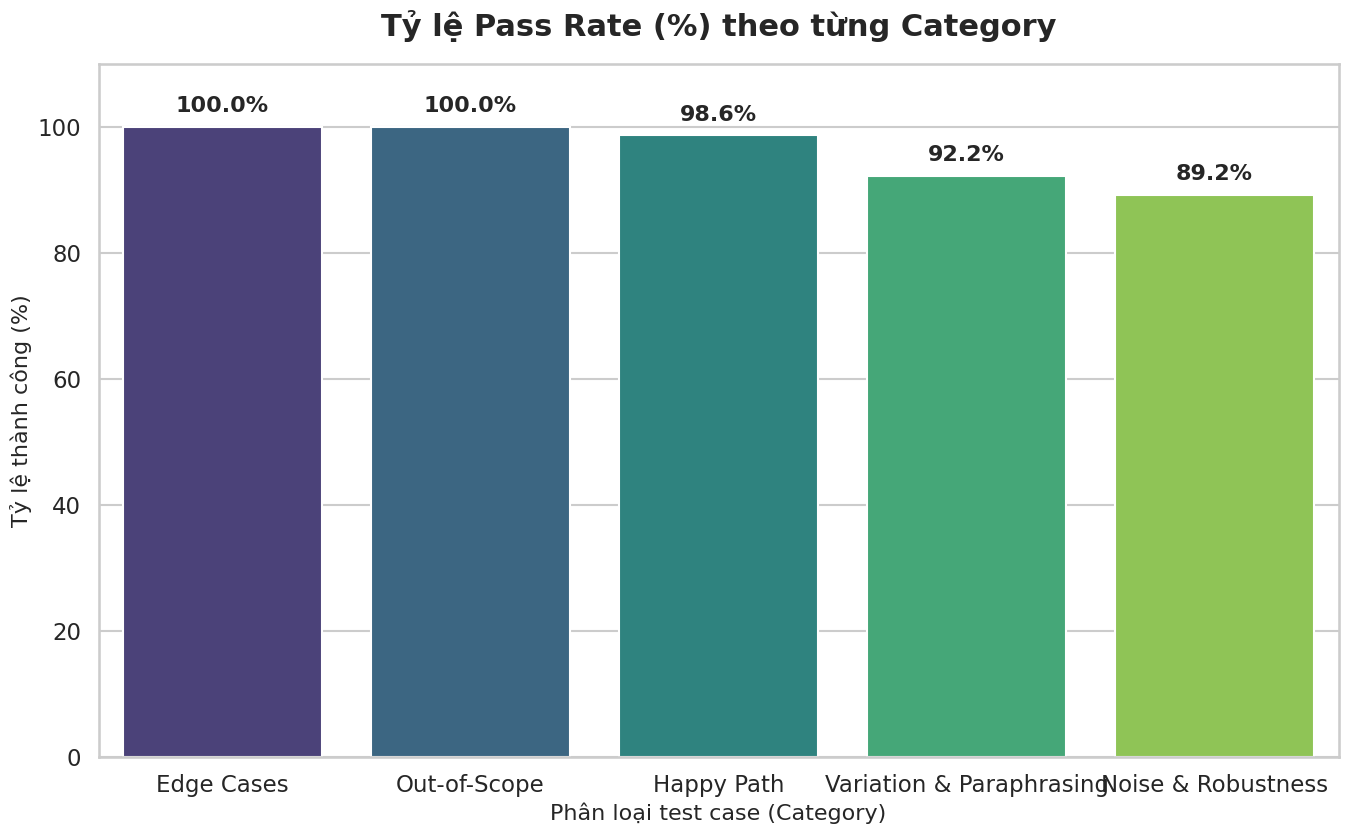

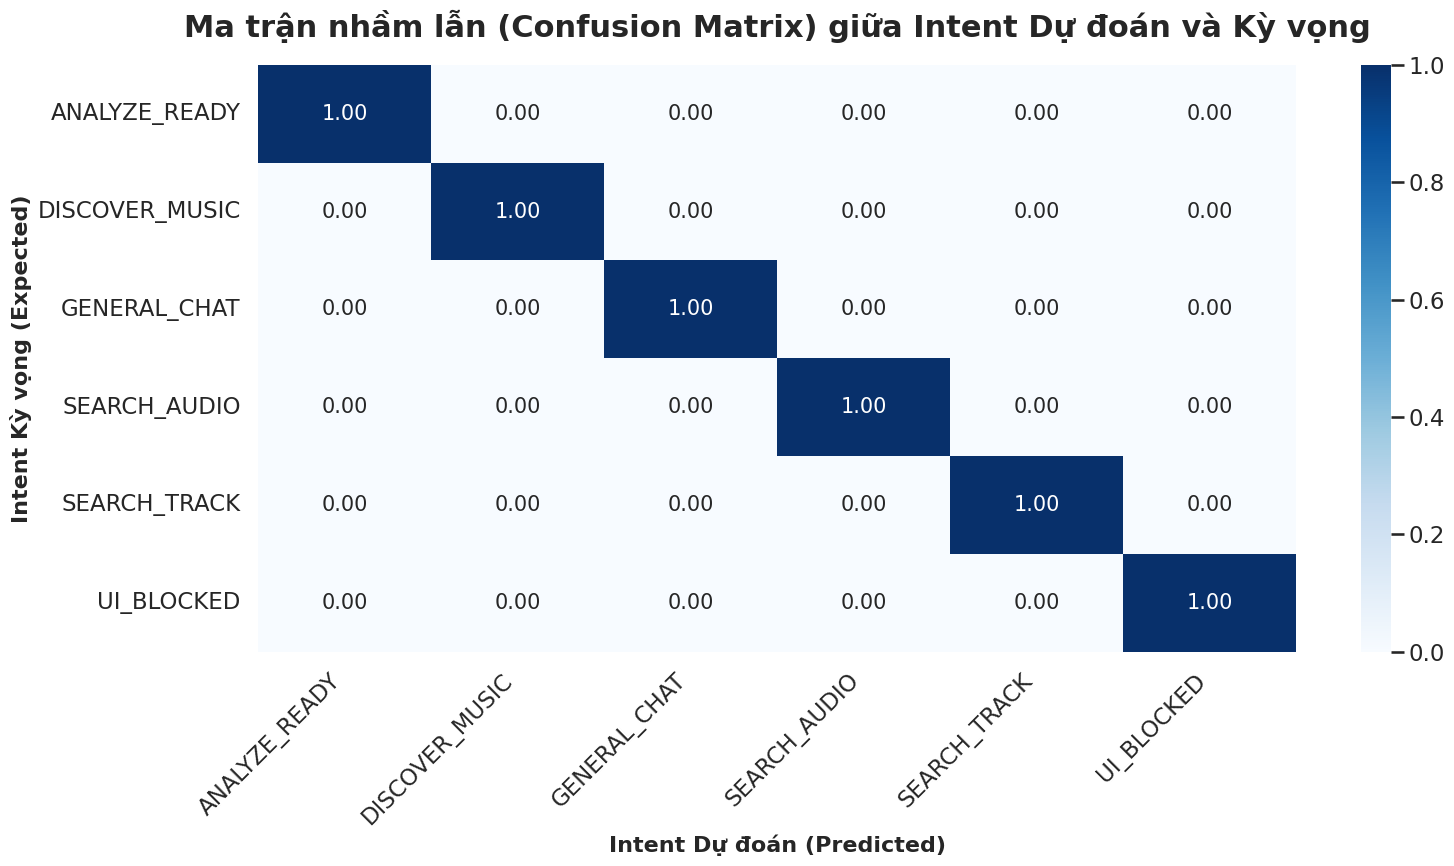

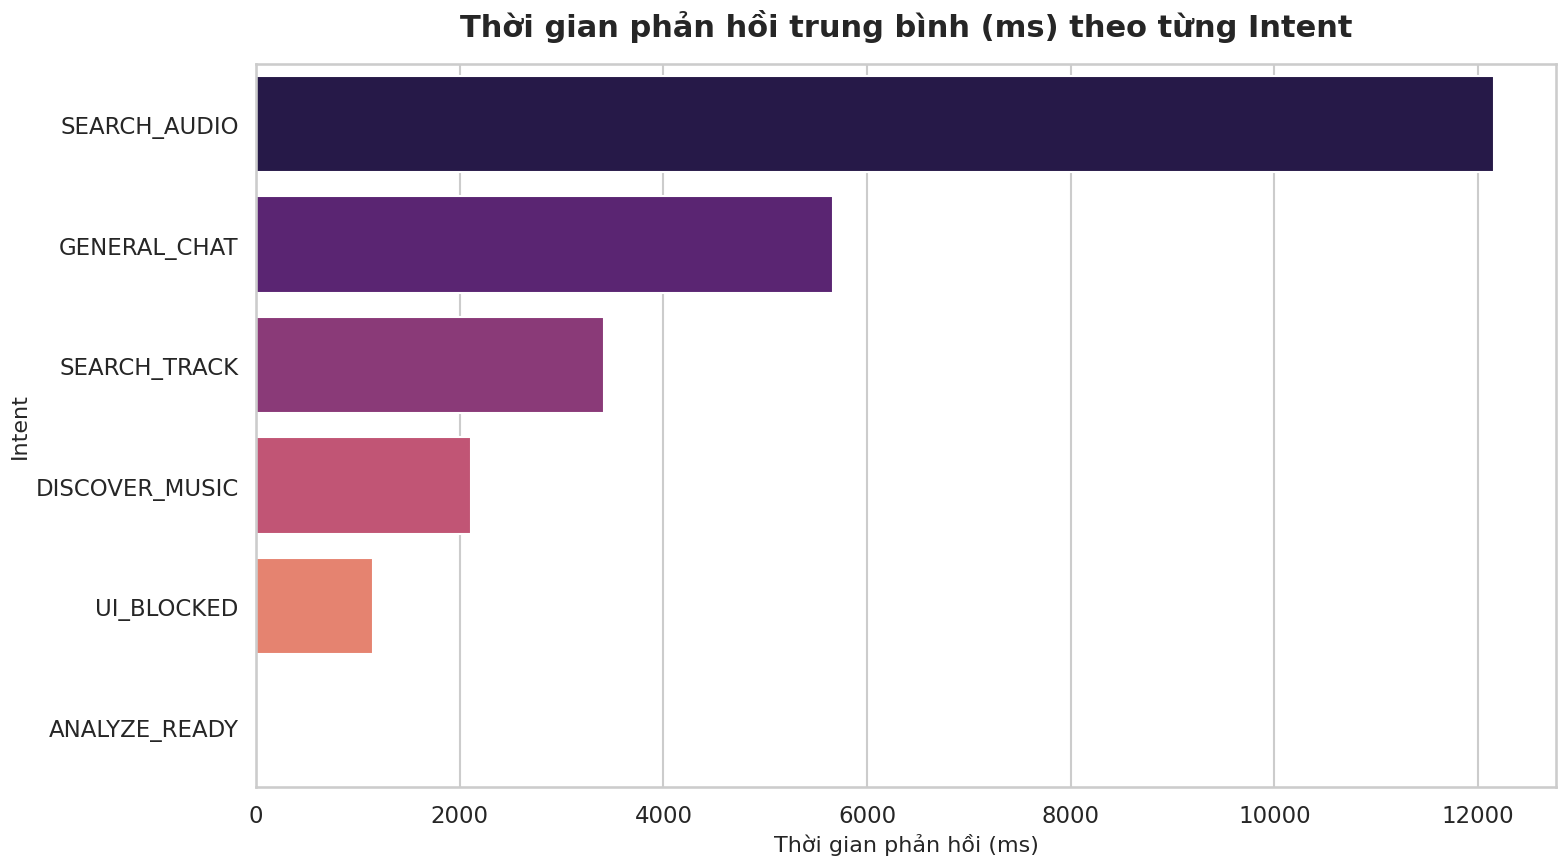

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Đọc dữ liệu
df = pd.read_csv('final_thesis_evaluation_report.csv')

# 2. Tiền xử lý dữ liệu
df['Category'] = df['Category'].replace('Edge Case', 'Edge Cases')
df['Total Response Time (ms)'] = pd.to_numeric(df['Total Response Time (ms)'], errors='coerce')
df['Is_Pass'] = df['Evaluation'].apply(lambda x: 1 if x == 'PASS' else 0)

# --- NÂNG CẤP CHẤT LƯỢNG HÌNH ẢNH (FULL HD / 4K) ---
# Dùng context='talk' để đường nét và chữ to, rõ ràng hơn khi chèn vào Word
sns.set_theme(style="whitegrid", context="talk") 
plt.rcParams['font.family'] = 'DejaVu Sans' # Đổi thành 'Arial' hoặc 'Times New Roman' nếu muốn

# Kích thước khung hình tỷ lệ 16:9
fig_size = (16, 9) 

# --- BIỂU ĐỒ 1: Tỷ lệ Pass Rate theo Category ---
plt.figure(figsize=fig_size)
acc_per_cat = df.groupby('Category')['Is_Pass'].mean() * 100
acc_per_cat = acc_per_cat.sort_values(ascending=False).reset_index()

ax = sns.barplot(data=acc_per_cat, x='Category', y='Is_Pass', palette='viridis')
plt.title('Tỷ lệ Pass Rate (%) theo từng Category', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Tỷ lệ thành công (%)', fontsize=16)
plt.xlabel('Phân loại test case (Category)', fontsize=16)
plt.ylim(0, 110)

# Ghi số liệu lên đầu cột to và rõ hơn
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 15), textcoords='offset points', 
                fontsize=16, fontweight='bold')

# Dùng bbox_inches='tight' để lấy trọn vẹn hình không bị lẹm
plt.savefig('ch4_pass_rate_FHD.png', dpi=400, bbox_inches='tight')

# --- BIỂU ĐỒ 2: Ma trận nhầm lẫn (Confusion Matrix) Intent ---
plt.figure(figsize=fig_size)
valid_intents = df['Expected Intent'].unique()
cm_data = df[df['Predicted Intent'].isin(valid_intents)]

cm = pd.crosstab(cm_data['Expected Intent'], cm_data['Predicted Intent'], normalize='index')

# Chỉnh size chữ bên trong ô Heatmap
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', annot_kws={"size": 15})
plt.title('Ma trận nhầm lẫn (Confusion Matrix) giữa Intent Dự đoán và Kỳ vọng', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Intent Kỳ vọng (Expected)', fontsize=16, fontweight='bold')
plt.xlabel('Intent Dự đoán (Predicted)', fontsize=16, fontweight='bold')

# Xoay nhãn trục X để không bị đè lên nhau
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('ch4_confusion_matrix_FHD.png', dpi=400, bbox_inches='tight')

# --- BIỂU ĐỒ 3: Thời gian phản hồi trung bình theo Intent ---
plt.figure(figsize=fig_size)
avg_latency = df.groupby('Expected Intent')['Total Response Time (ms)'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=avg_latency, x='Total Response Time (ms)', y='Expected Intent', palette='magma')
plt.title('Thời gian phản hồi trung bình (ms) theo từng Intent', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Thời gian phản hồi (ms)', fontsize=16)
plt.ylabel('Intent', fontsize=16)

plt.tight_layout()
plt.savefig('ch4_latency_FHD.png', dpi=400, bbox_inches='tight')

print("Đã xuất xong 3 biểu đồ chuẩn độ phân giải cực cao!")

THỐNG KÊ TẬP DỮ LIỆU KIỂM THỬ (TEST SET EDA - CHƯƠNG 4.1)
Tổng số Test Case: 370

1. Phân bổ theo Category:
Category
Happy Path                  147
Variation & Paraphrasing    115
Edge Cases                   42
Noise & Robustness           37
Out-of-Scope                 29

2. Phân bổ theo Intent Kỳ vọng (Top 10):
Expected Intent
DISCOVER_MUSIC    183
GENERAL_CHAT       84
SEARCH_TRACK       58
UI_BLOCKED         20
ANALYZE_READY      13
SEARCH_AUDIO       12

3. Thống kê chiều dài câu truy vấn (Số từ):
- Ngắn nhất: 1 từ
- Dài nhất:  18 từ
- Trung bình: 7.7 từ
- Trung vị (50%): 8 từ


C:\Users\huyen\AppData\Local\Temp\ipykernel_17828\3643380540.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='Blues_r')
C:\Users\huyen\AppData\Local\Temp\ipykernel_17828\3643380540.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, y='Expected Intent', order=df['Expected Intent'].value_counts().index, palette='crest')


Đã xuất xong 3 biểu đồ Full HD!


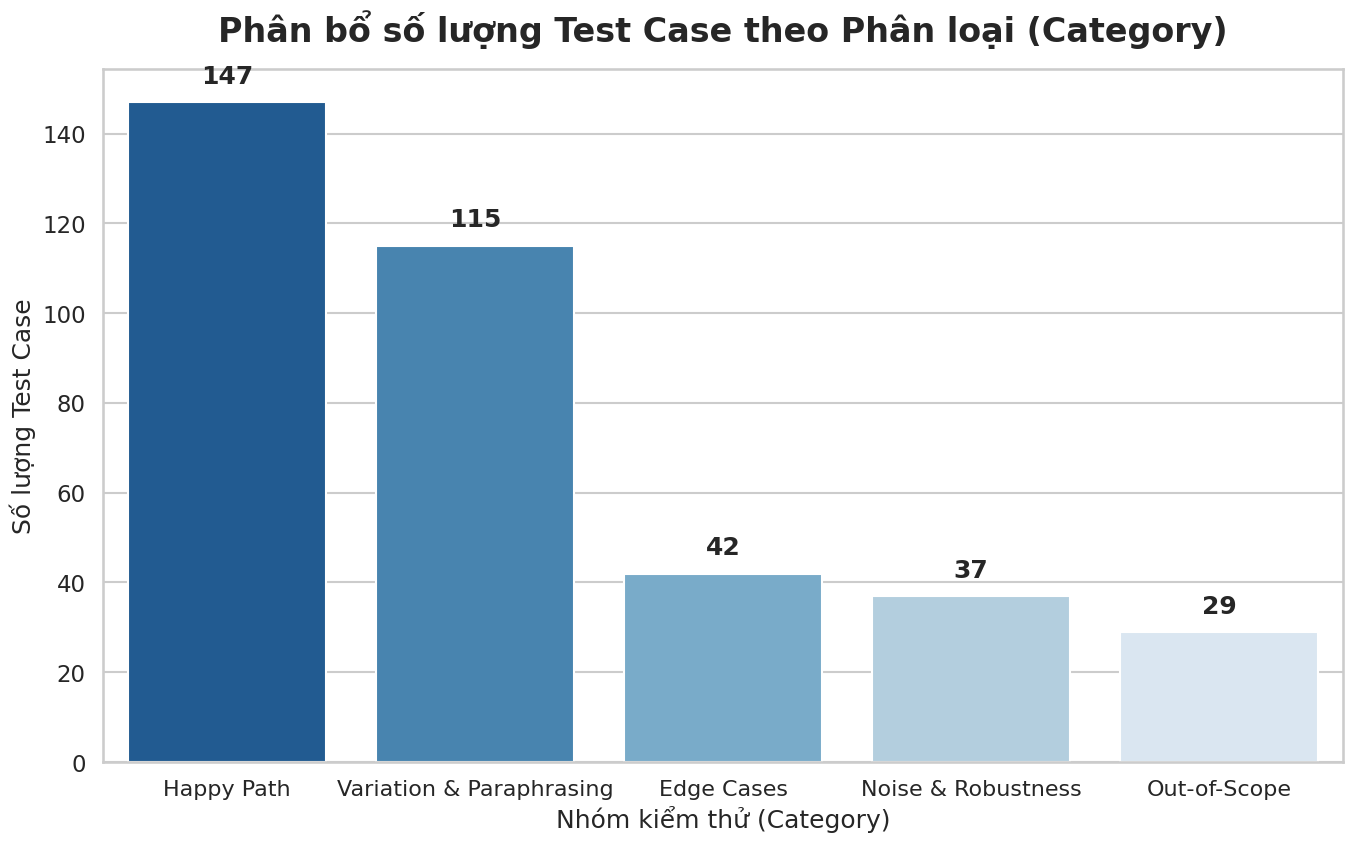

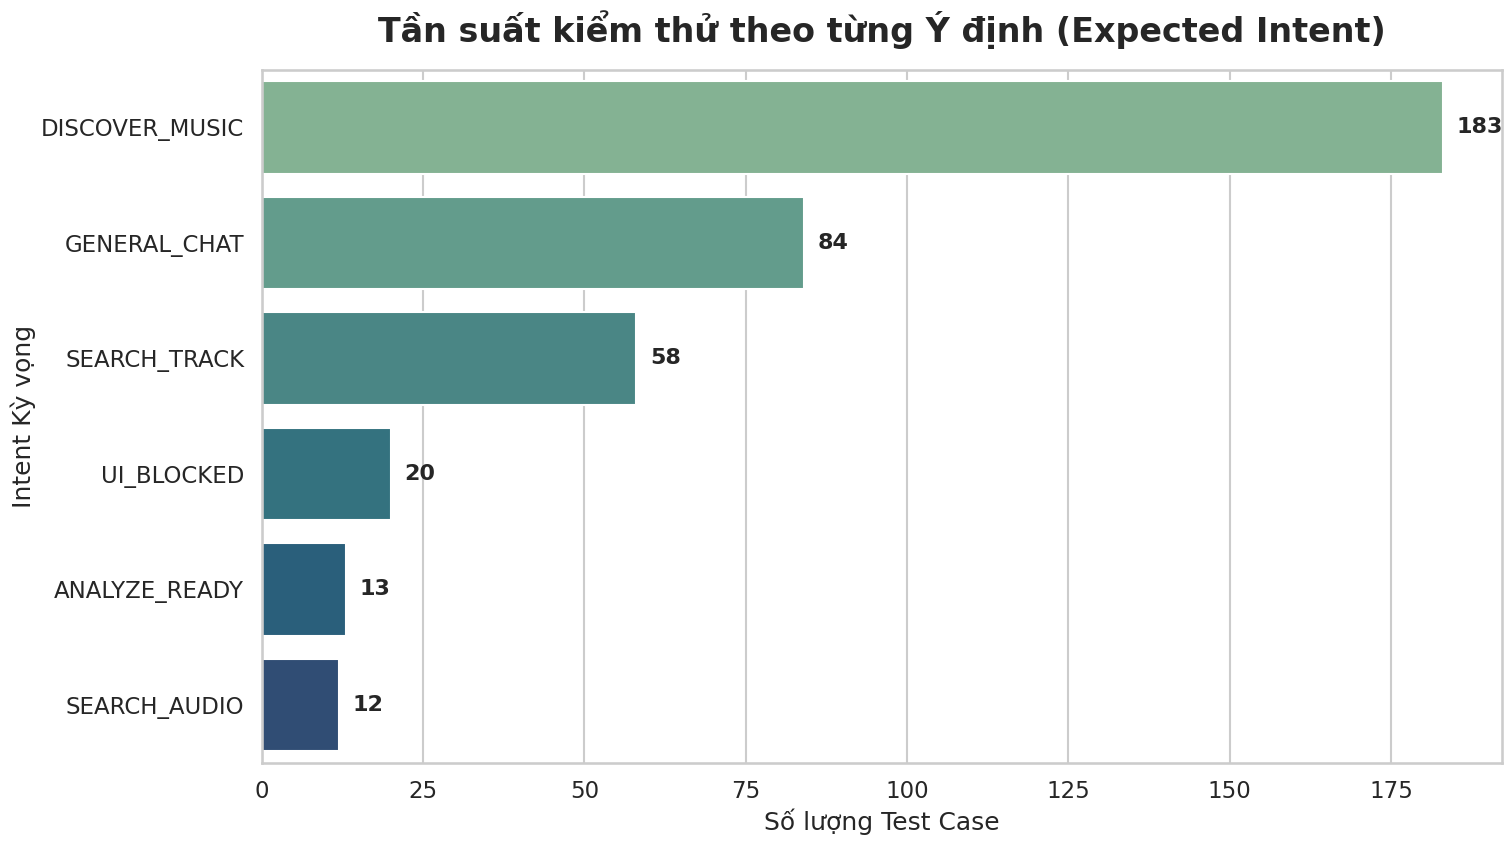

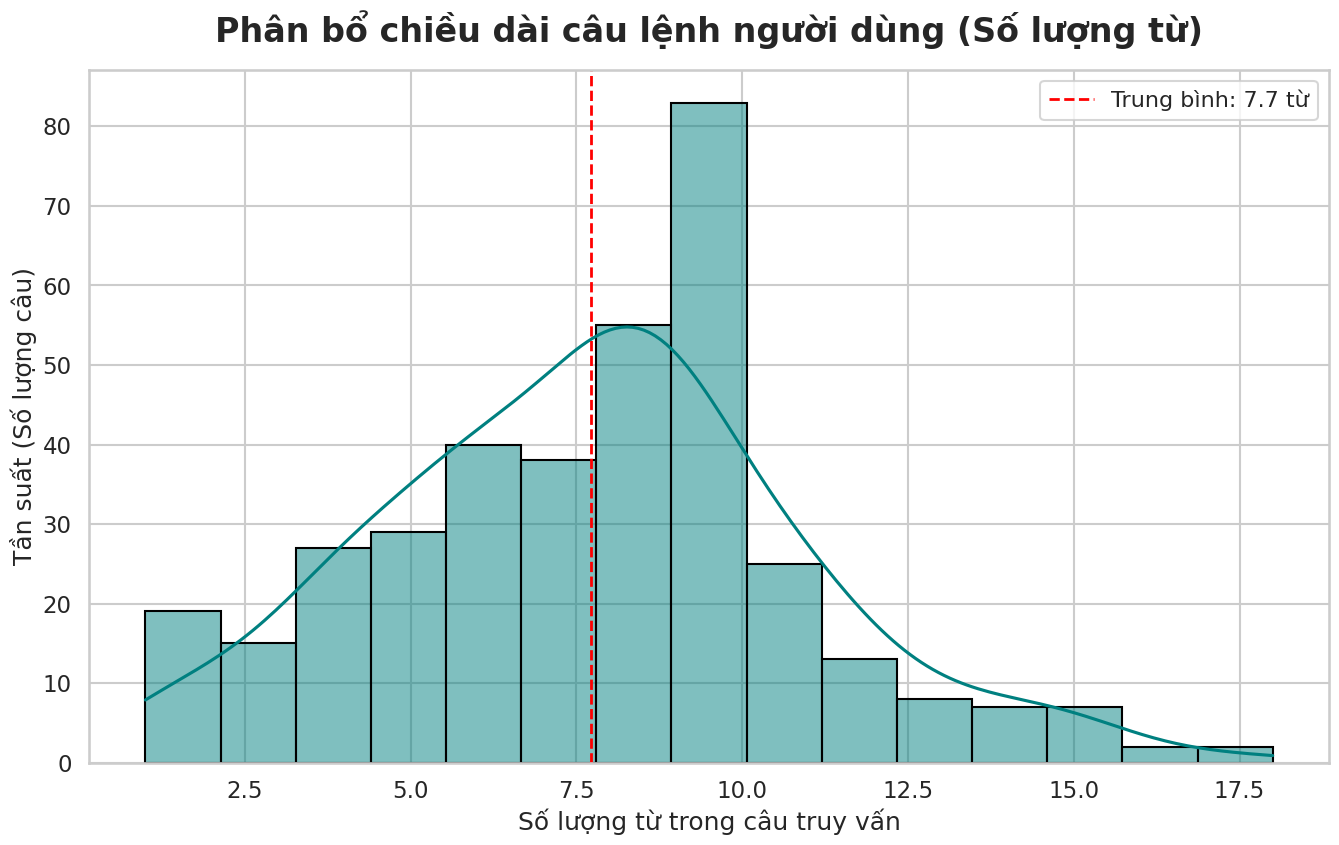

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
df = pd.read_csv('final_thesis_evaluation_report.csv')

# 2. Tiền xử lý nhanh cho EDA
df['Category'] = df['Category'].replace('Edge Case', 'Edge Cases')
df['Query_Word_Count'] = df['User Query'].apply(lambda x: len(str(x).split()))

# =====================================================================
# PHẦN 1: IN SỐ LIỆU RA MÀN HÌNH (Để copy vào báo cáo)
# =====================================================================
print("="*60)
print("THỐNG KÊ TẬP DỮ LIỆU KIỂM THỬ (TEST SET EDA - CHƯƠNG 4.1)")
print("="*60)
print(f"Tổng số Test Case: {len(df)}")
print("\n1. Phân bổ theo Category:")
print(df['Category'].value_counts().to_string())

print("\n2. Phân bổ theo Intent Kỳ vọng (Top 10):")
print(df['Expected Intent'].value_counts().head(10).to_string())

print("\n3. Thống kê chiều dài câu truy vấn (Số từ):")
word_stats = df['Query_Word_Count'].describe()
print(f"- Ngắn nhất: {int(word_stats['min'])} từ")
print(f"- Dài nhất:  {int(word_stats['max'])} từ")
print(f"- Trung bình: {word_stats['mean']:.1f} từ")
print(f"- Trung vị (50%): {int(word_stats['50%'])} từ")
print("="*60)

# =====================================================================
# PHẦN 2: XUẤT BIỂU ĐỒ FULL HD (Để chèn vào file Word)
# =====================================================================

# Thiết lập phong cách cho độ phân giải cao
sns.set_theme(style="whitegrid", context="talk") 
plt.rcParams['font.family'] = 'DejaVu Sans'
fig_size = (16, 9)

# --- EDA 1: Phân bổ số lượng Test Case theo từng Category ---
plt.figure(figsize=fig_size)
ax1 = sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='Blues_r')

plt.title('Phân bổ số lượng Test Case theo Phân loại (Category)', fontsize=24, fontweight='bold', pad=20)
plt.ylabel('Số lượng Test Case', fontsize=18)
plt.xlabel('Nhóm kiểm thử (Category)', fontsize=18)
plt.xticks(rotation=0, fontsize=16) # Để tỷ lệ 16:9 thì chữ sẽ vừa vặn, không cần nghiêng

# Ghi số lượng lên đầu cột
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 10), textcoords='offset points', 
                fontsize=18, fontweight='bold')

plt.savefig('eda1_category_distribution_FHD.png', dpi=400, bbox_inches='tight')

# --- EDA 2: Tần suất kiểm thử của các Intent kỳ vọng ---
plt.figure(figsize=fig_size)
ax2 = sns.countplot(data=df, y='Expected Intent', order=df['Expected Intent'].value_counts().index, palette='crest')

plt.title('Tần suất kiểm thử theo từng Ý định (Expected Intent)', fontsize=24, fontweight='bold', pad=20)
plt.xlabel('Số lượng Test Case', fontsize=18)
plt.ylabel('Intent Kỳ vọng', fontsize=18)

# Ghi số lượng ngay bên cạnh thanh ngang
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(10, 0), textcoords='offset points', 
                fontsize=16, fontweight='bold')

plt.savefig('eda2_intent_distribution_FHD.png', dpi=400, bbox_inches='tight')

# --- EDA 3: Phân bổ chiều dài câu truy vấn (Word Count) ---
plt.figure(figsize=fig_size)
sns.histplot(data=df, x='Query_Word_Count', bins=15, kde=True, color='teal', edgecolor='black')

plt.title('Phân bổ chiều dài câu lệnh người dùng (Số lượng từ)', fontsize=24, fontweight='bold', pad=20)
plt.xlabel('Số lượng từ trong câu truy vấn', fontsize=18)
plt.ylabel('Tần suất (Số lượng câu)', fontsize=18)

# Đánh dấu đường trung bình (Mean)
mean_val = df['Query_Word_Count'].mean()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Trung bình: {mean_val:.1f} từ')
plt.legend(fontsize=16)

plt.savefig('eda3_query_length_FHD.png', dpi=400, bbox_inches='tight')

print("Đã xuất xong 3 biểu đồ Full HD!")